In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "swanson_7K_pbmc_teaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

Downloading bucket files: 475687619 / 475687619 complete

Downloading bytes: 475687619 / 475687619 complete

In [2]:
assay_inventory = []
for assay_name in ("RNA", "ATAC", "ADT"):
    assay = ds.get_assay(assay_name)
    assay_inventory.append(
        {
            "assay": assay_name,
            "cells": assay.rawData.shape[0],
            "raw features": assay.rawData.shape[1],
            "active features": int(assay.feats.fetch_all("I").sum()),
        }
    )

pd.DataFrame(assay_inventory)

,assay,cells,raw features,active features
0,RNA,7069,36601,13345
1,ATAC,7069,240122,160049
2,ADT,7069,46,45


In [3]:
active_cells = int(ds.cells.fetch_all("I").sum())
pd.Series(
    {
        "source cells retained": ds.cells.N,
        "active exact W3 matches": active_cells,
        "Figure 4 W3 labels": 6_333,
        "Figure 4 labels absent from the pinned RDS": 139,
    }
)

source cells retained                         7069
active exact W3 matches                       6194
Figure 4 W3 labels                            6333
Figure 4 labels absent from the pinned RDS     139
dtype: int64

In [4]:
pd.Series(ds.cells.fetch("tea_cell_type", key="I")).value_counts()

T.CD4.Memory        1450
T.CD4.Naive         1274
B.Naive              981
Mono.CD14            789
T.CD8.Effector       709
T.CD8.Naive          372
NK                   351
B.Activated          205
Mono.CD16             39
Platelets             14
DC.Myeloid             9
T.DoubleNegative       1
Name: count, dtype: int64

In [5]:
preprocessing = pd.DataFrame(
    [
        {
            "assay": "RNA",
            "normalization": "library-size log1p",
            "feature selection": "2,000 HVGs",
            "reduction": "30-component PCA",
        },
        {
            "assay": "ATAC",
            "normalization": "TF-IDF",
            "feature selection": "25,000 prevalent peaks",
            "reduction": "30-component streaming LSI, first component skipped",
        },
        {
            "assay": "ADT",
            "normalization": "CLR",
            "feature selection": "exclude isotype control",
            "reduction": "15-component PCA",
        },
    ]
)
preprocessing

,assay,normalization,feature selection,reduction
0,RNA,library-size log1p,"2,000 HVGs",30-component PCA
1,ATAC,TF-IDF,"25,000 prevalent peaks","30-component streaming LSI, first component sk..."
2,ADT,CLR,exclude isotype control,15-component PCA


In [6]:
artifact_rows = []
for assay in ("RNA", "ATAC", "ADT"):
    for kind in (
        "normalized",
        "feature_selection",
        "reduction",
        "neighbors",
    ):
        for ref in ds.list_artifacts(
            from_assay=assay,
            kind=kind,
            complete_only=True,
        ):
            status = ds.inspect_artifact(ref)
            parameters = status.parameters or {}
            artifact_rows.append(
                {
                    "assay": assay,
                    "kind": kind,
                    "operation": status.operation,
                    "artifact": ref.artifact_id[:12],
                    "label": None,
                    "method": None,
                    "dims": parameters.get("dims"),
                    "k": parameters.get("k"),
                    "top_n": parameters.get("top_n"),
                    "skip_first": parameters.get("skip_first"),
                }
            )
for ref in ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    complete_only=True,
):
    status = ds.inspect_artifact(ref)
    options = status.execution_options or {}
    parameters = status.parameters or {}
    artifact_rows.append(
        {
            "assay": "datastore",
            "kind": ref.kind,
            "operation": status.operation,
            "artifact": ref.artifact_id[:12],
            "label": options.get("label"),
            "method": parameters.get("method"),
            "dims": None,
            "k": None,
            "top_n": None,
            "skip_first": None,
        }
    )
pd.DataFrame(artifact_rows)

,assay,kind,operation,artifact,label,method,dims,k,top_n,skip_first
0,RNA,normalized,run_normalization,62d351efeeca,None,None,NaN,NaN,NaN,None
1,RNA,feature_selection,mark_hvgs,c076d3be2ffc,None,None,NaN,NaN,2000.0,None
2,RNA,reduction,run_pca,ec30b76fc07d,None,None,30.0,NaN,NaN,None
3,RNA,neighbors,query_neighbors,1ec3b90e8509,None,None,NaN,20.0,NaN,None
4,ATAC,normalized,run_normalization,1c3c640b8492,None,None,NaN,NaN,NaN,None
5,ATAC,feature_selection,mark_prevalent_peaks,b5efc82b3c3e,None,None,NaN,NaN,25000.0,None
6,ATAC,feature_selection,manual_selection,e62b4a93b696,None,None,NaN,NaN,NaN,None
7,ATAC,reduction,run_lsi,5d923092ca37,None,None,30.0,NaN,NaN,True
8,ATAC,neighbors,query_neighbors,ad5390689024,None,None,NaN,20.0,NaN,None
9,ADT,normalized,run_normalization,4cea7cfc538a,None,None,NaN,NaN,NaN,None


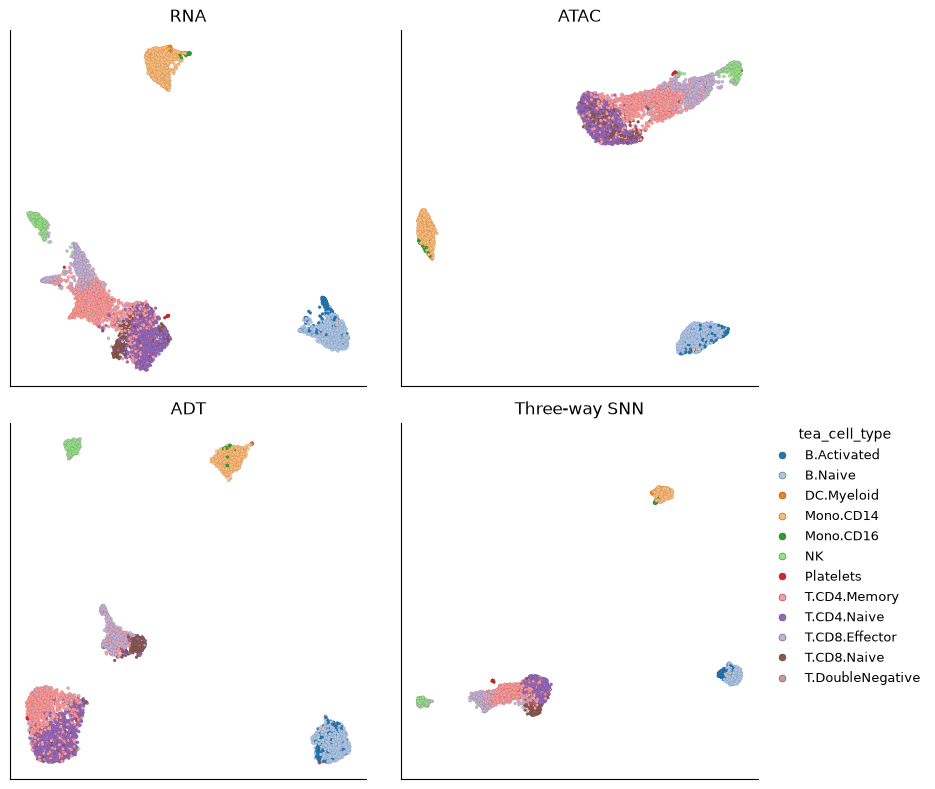

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
layout_panels = (
    ("RNA", "RNA_UMAP"),
    ("ATAC", "ATAC_UMAP"),
    ("ADT", "ADT_UMAP"),
    ("Three-way SNN", "RNA+ATAC+ADT_UMAP"),
)
for index, (axis, (title, layout_key)) in enumerate(
    zip(axes.flat, layout_panels, strict=True)
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by="tea_cell_type",
        point_size=5,
        legend_loc="right",
        show_legend=index == len(layout_panels) - 1,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

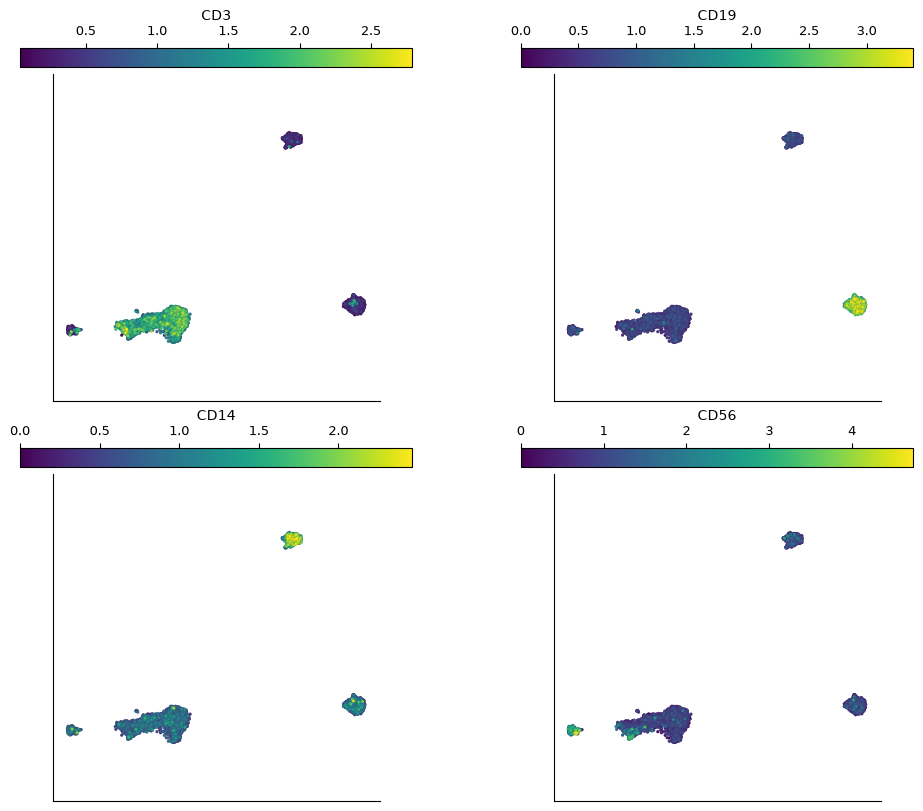

In [8]:
snn_markers = ds.plots.embedding(
    layout_key="RNA+ATAC+ADT_UMAP",
    from_assay="ADT",
    color_by=["CD3", "CD19", "CD14", "CD56"],
    n_columns=2,
    point_size=5,
    sort_values=True,
    show_titles=True,
    show=False,
)
snn_markers.figure.set_size_inches(10, 8)

In [9]:
assays = ["RNA", "ATAC", "ADT"]
existing_wnn = next(
    ref
    for ref in ds.list_artifacts(
        scope="datastore",
        kind="integrated_graph",
        complete_only=True,
    )
    if (ds.inspect_artifact(ref).execution_options or {}).get("label")
    == "RNA+ATAC+ADT_wnn"
)
reused_wnn = ds.integrate_assays(
    assays=assays,
    label="RNA+ATAC+ADT_wnn",
    method="wnn",
    l2_normalize=True,
)
wnn_status = ds.inspect_artifact(reused_wnn)

assert reused_wnn == existing_wnn
assert wnn_status.parameters["assays"] == assays
pd.Series(
    {
        "artifact reused": reused_wnn == existing_wnn,
        "artifact id": reused_wnn.artifact_id,
        "complete": wnn_status.complete,
    }
)

artifact reused                                                 True
artifact id        4476be95c42c9d67f46c78050c0529ff2482b810cc9cd2...
complete                                                        True
dtype: object

In [10]:
weight_columns = [
    f"RNA+ATAC+ADT_wnn_{assay}_weight" for assay in assays
]
weight_values = np.column_stack(
    [ds.cells.fetch(column, key="I") for column in weight_columns]
)

assert weight_values.shape == (6_194, 3)
assert np.isfinite(weight_values).all()
assert (weight_values >= 0).all()
assert np.allclose(weight_values.sum(axis=1), 1, atol=1e-6)

pd.Series(
    {
        "shape": str(weight_values.shape),
        "minimum weight": float(weight_values.min()),
        "maximum weight": float(weight_values.max()),
        "maximum row-sum error": float(
            np.abs(weight_values.sum(axis=1) - 1).max()
        ),
    }
)

shape                    (6194, 3)
minimum weight                 0.0
maximum weight                 1.0
maximum row-sum error          0.0
dtype: object

In [11]:
weight_frame = pd.DataFrame(
    {
        "RNA weight": weight_values[:, 0],
        "ATAC weight": weight_values[:, 1],
        "ADT weight": weight_values[:, 2],
        "tea_cell_type": ds.cells.fetch("tea_cell_type", key="I"),
    }
)
weight_frame.groupby("tea_cell_type")[
    ["RNA weight", "ATAC weight", "ADT weight"]
].agg(["count", "mean"]).round(3)

RNA weight        ATAC weight        ADT weight       
                      count   mean       count   mean      count   mean
tea_cell_type                                                          
B.Activated             205  0.285         205  0.493        205  0.222
B.Naive                 981  0.187         981  0.465        981  0.347
DC.Myeloid                9  0.188           9  0.240          9  0.572
Mono.CD14               789  0.407         789  0.200        789  0.394
Mono.CD16                39  0.868          39  0.048         39  0.084
NK                      351  0.259         351  0.361        351  0.380
Platelets                14  0.284          14  0.248         14  0.468
T.CD4.Memory           1450  0.143        1450  0.310       1450  0.547
T.CD4.Naive            1274  0.141        1274  0.229       1274  0.630
T.CD8.Effector          709  0.174         709  0.371        709  0.455
T.CD8.Naive             372  0.109         372  0.191        372  0.700
T.DoubleNegative          1  0.000           1  0.000          1  1.000

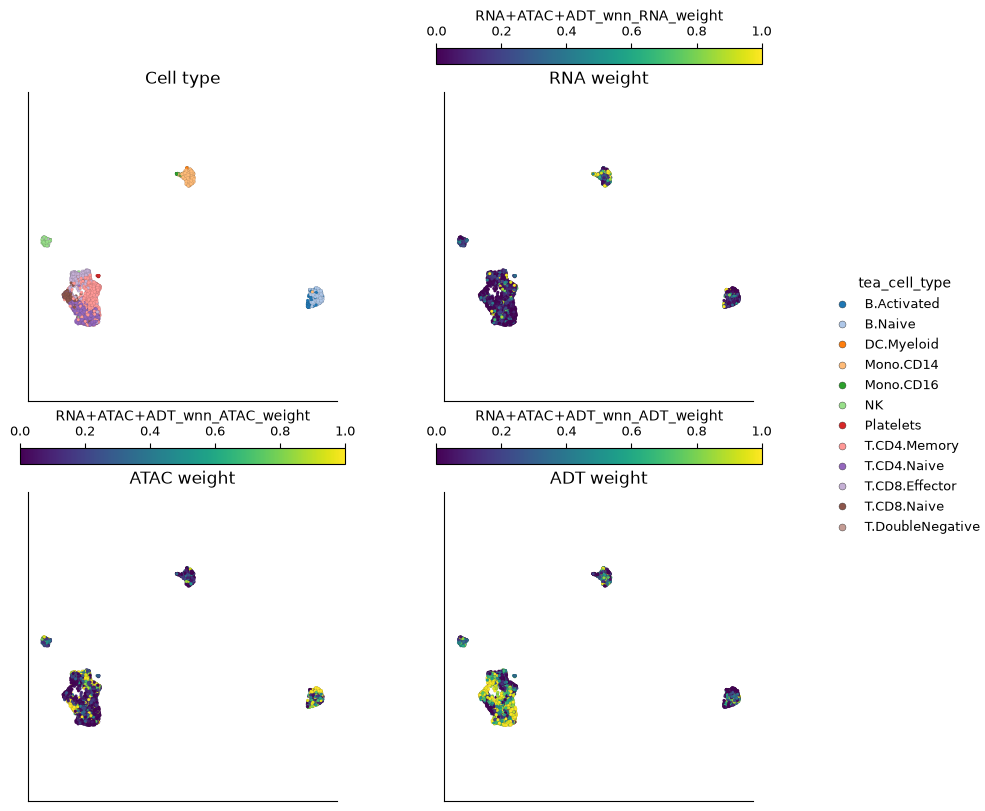

In [12]:
wnn_view = ds.plots.embedding(
    layout_key="RNA+ATAC+ADT_wnn_UMAP",
    color_by=["tea_cell_type", *weight_columns],
    n_columns=2,
    point_size=5,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    wnn_view.axes.values(),
    ("Cell type", "RNA weight", "ATAC weight", "ADT weight"),
    strict=True,
):
    axis.set_title(title)
wnn_view.figure.set_size_inches(10, 8)

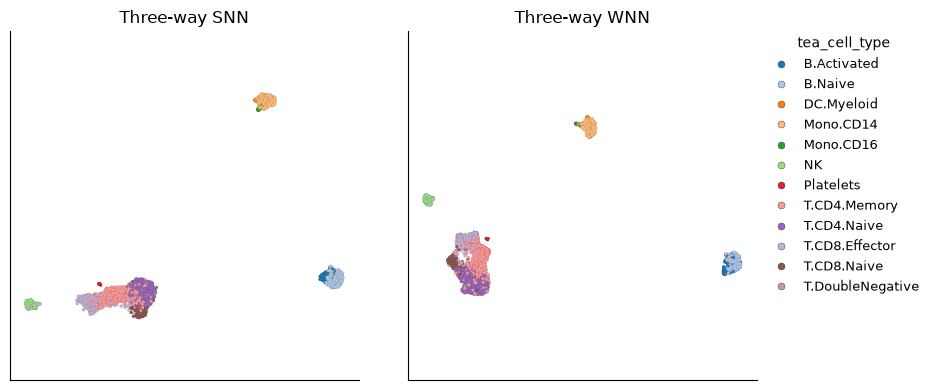

In [13]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
integration_panels = (
    ("Three-way SNN", "RNA+ATAC+ADT_UMAP"),
    ("Three-way WNN", "RNA+ATAC+ADT_wnn_UMAP"),
)
for index, (axis, (title, layout_key)) in enumerate(
    zip(axes, integration_panels, strict=True)
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by="tea_cell_type",
        point_size=5,
        legend_loc="right",
        show_legend=index == 1,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

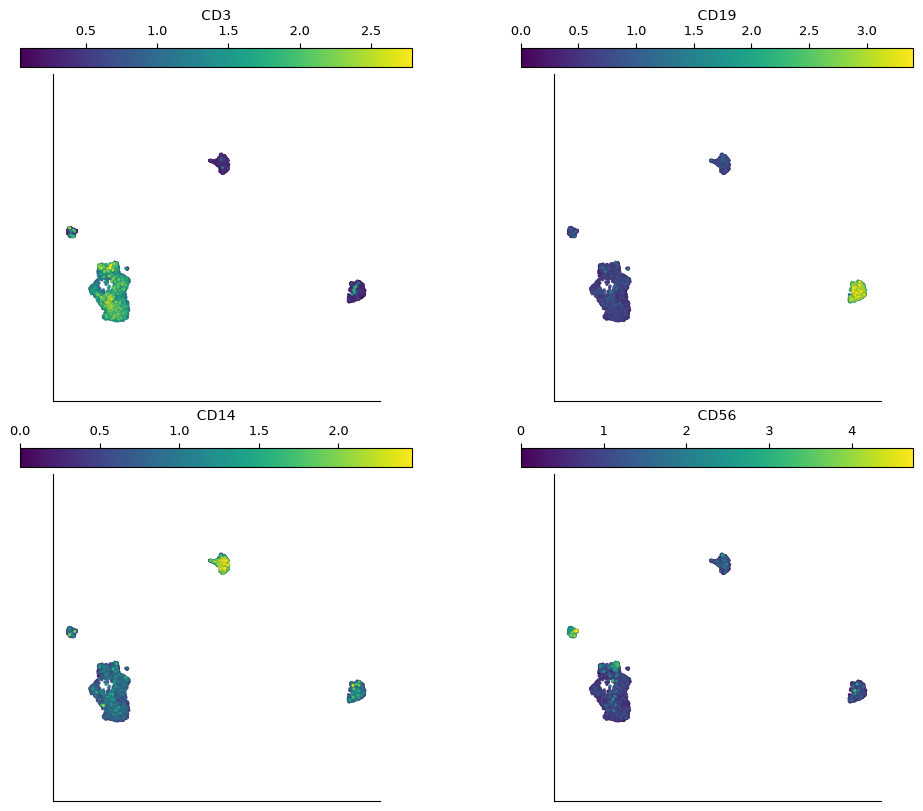

In [14]:
wnn_markers = ds.plots.embedding(
    layout_key="RNA+ATAC+ADT_wnn_UMAP",
    from_assay="ADT",
    color_by=["CD3", "CD19", "CD14", "CD56"],
    n_columns=2,
    point_size=5,
    sort_values=True,
    show_titles=True,
    show=False,
)
wnn_markers.figure.set_size_inches(10, 8)